In [ ]:
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **I. Import data**

In [ ]:
# Giải nén tệp
!unzip -o -q "/content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data/raw/archive.zip" -d /content/data

# Thiết lập đường dẫn thư mục dựa trên cấu trúc thực tế
data_dir = '/content/data/Dataset'

print("Giải nén và cập nhật đường dẫn hoàn tất.")

Giải nén và cập nhật đường dẫn hoàn tất.


In [ ]:
# Liệt kê các thư mục con trong data_dir, mỗi thư mục tương ứng với một class
classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])

print(classes)

['A', 'AA', 'AAA', 'B', 'C', 'D', 'DD', 'E', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'OOO', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y']


## 1. Xử lý dữ liệu trùng lặp

In [ ]:
import shutil

# Đường dẫn tới thư mục class AAA
class_to_remove = 'AAA'
path_to_remove = os.path.join(data_dir, class_to_remove)

shutil.rmtree(path_to_remove)
print(f"Đã xóa thành công thư mục: {path_to_remove}")


# Cập nhật lại danh sách classes
classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
print(f"Danh sách class mới ({len(classes)} lớp):")
print(classes)

Đã xóa thành công thư mục: /content/data/Dataset/AAA
Danh sách class mới (25 lớp):
['A', 'AA', 'B', 'C', 'D', 'DD', 'E', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'OOO', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y']


In [ ]:
total_samples = 0
print(f"{'Class':<10} | {'Count':<10}")
print("-" * 25)

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
    print(f"{cls:<10} | {count:<10}")
    total_samples += count

print("-" * 25)
print(f"Tổng số mẫu hiện tại: {total_samples}")

Class      | Count     
-------------------------
A          | 1000      
AA         | 1000      
B          | 1000      
C          | 1000      
D          | 1000      
DD         | 1000      
E          | 1000      
G          | 1000      
H          | 1000      
I          | 1000      
K          | 1000      
L          | 1000      
M          | 1000      
N          | 1000      
O          | 1000      
OOO        | 1000      
P          | 1000      
Q          | 1000      
R          | 1000      
S          | 1000      
T          | 1000      
U          | 1000      
V          | 1000      
X          | 1000      
Y          | 1000      
-------------------------
Tổng số mẫu hiện tại: 25000


## 2. Tách dữ liệu

In [ ]:
import tensorflow as tf

# Thiết lập các tham số
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
SEED = 42

# 1. Load toàn bộ tập dữ liệu từ thư mục
# Dùng validation_split của TF để lấy 20% cho (Val + Test) trước
full_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    shuffle=True,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 2. Tính toán số lượng batch để chia thủ công
dataset_size = tf.data.experimental.cardinality(full_dataset).numpy()
train_size = int(0.8 * dataset_size)
val_test_size = dataset_size - train_size
val_size = int(0.5 * val_test_size) # 10% tổng là một nửa của 20% còn lại
test_size = val_test_size - val_size

# 3. Thực hiện tách
train_ds = full_dataset.take(train_size)
remaining_ds = full_dataset.skip(train_size)
val_ds = remaining_ds.take(val_size)
test_ds = remaining_ds.skip(val_size)

print(f"\nTổng số batches: {dataset_size}")
print(f"Train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Val batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

Found 25000 files belonging to 25 classes.

Tổng số batches: 782
Train batches: 625
Val batches: 78
Test batches: 79


## 3. Lưu tập train, val, test vào drive

In [ ]:
output_dir = '/content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data'

In [ ]:
# Tạo các đường dẫn con
train_path = os.path.join(output_dir, 'train_ds')
val_path = os.path.join(output_dir, 'val_ds')
test_path = os.path.join(output_dir, 'test_ds')

# Lưu dữ liệu
print("Đang lưu Train dataset...")
train_ds.save(train_path)

print("Đang lưu Val dataset...")
val_ds.save(val_path)

print("Đang lưu Test dataset...")
test_ds.save(test_path)

print(f"\nTất cả các tập dữ liệu đã được lưu tại: {output_dir}")

Đang lưu Train dataset...
Đang lưu Val dataset...
Đang lưu Test dataset...

Tất cả các tập dữ liệu đã được lưu tại: /content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data


## 4. Lấy dữ liệu vừa lưu ra kiểm tra

In [ ]:
train_path = '/content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data/train_ds'
val_path = '/content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data/val_ds'
test_path = '/content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data/test_ds'

In [ ]:
import tensorflow as tf

In [ ]:
# Tải lại các tập dữ liệu từ bộ nhớ
loaded_train = tf.data.Dataset.load(train_path)
loaded_val = tf.data.Dataset.load(val_path)
loaded_test = tf.data.Dataset.load(test_path)

# Kiểm tra số lượng batch
print("Kiểm tra dữ liệu sau khi tải:")
print(f"Train batches: {tf.data.experimental.cardinality(loaded_train).numpy()}")
print(f"Val batches: {tf.data.experimental.cardinality(loaded_val).numpy()}")
print(f"Test batches: {tf.data.experimental.cardinality(loaded_test).numpy()}")

# Lấy thử 1 batch từ tập test để xem cấu trúc
for images, labels in loaded_test.take(1):
    print(f"\nCấu trúc ảnh trong 1 batch: {images.shape}")
    print(f"Cấu trúc nhãn trong 1 batch: {labels.shape}")
    print("Tải dữ liệu thành công!")

Kiểm tra dữ liệu sau khi tải:
Train batches: 625
Val batches: 78
Test batches: 79

Cấu trúc ảnh trong 1 batch: (32, 224, 224, 3)
Cấu trúc nhãn trong 1 batch: (32,)
Tải dữ liệu thành công!


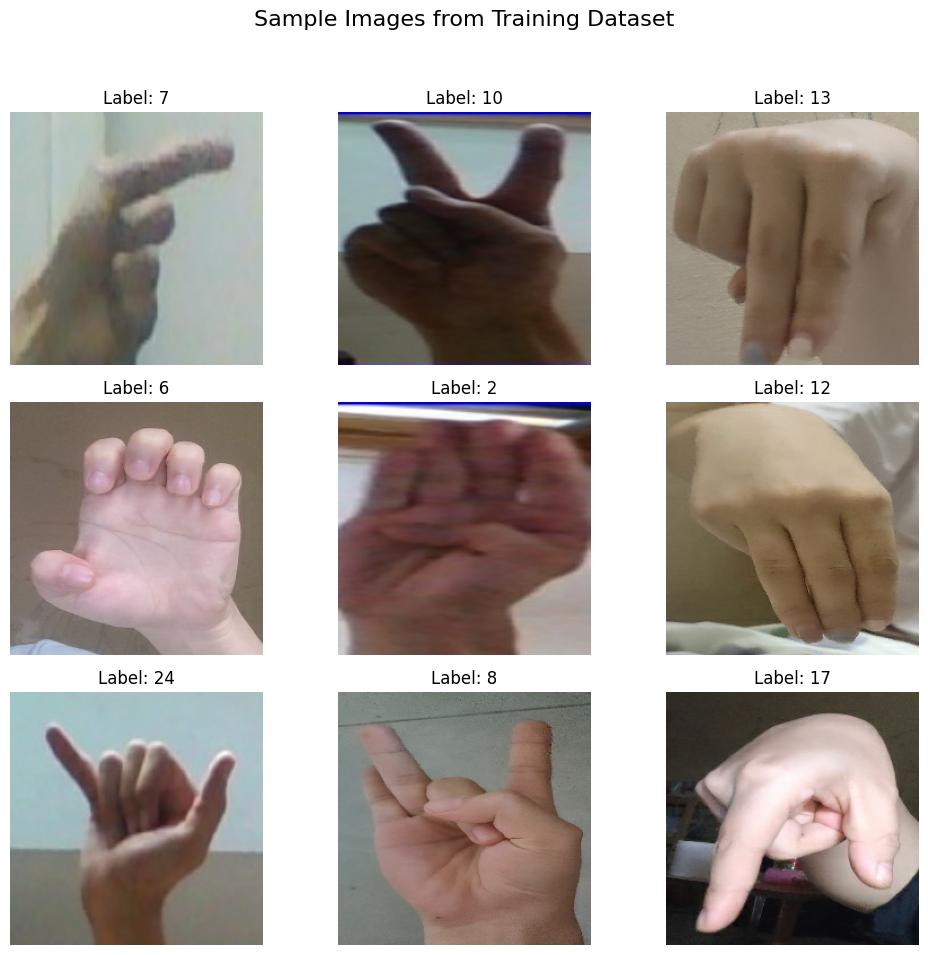

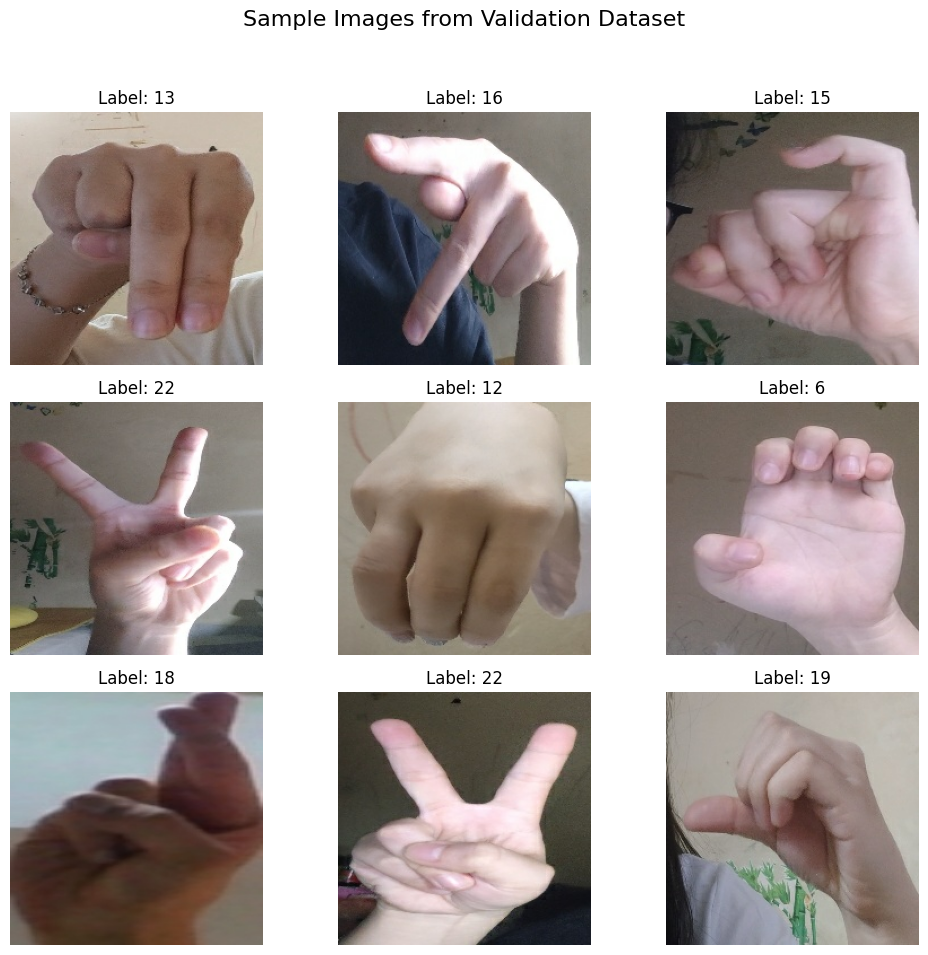

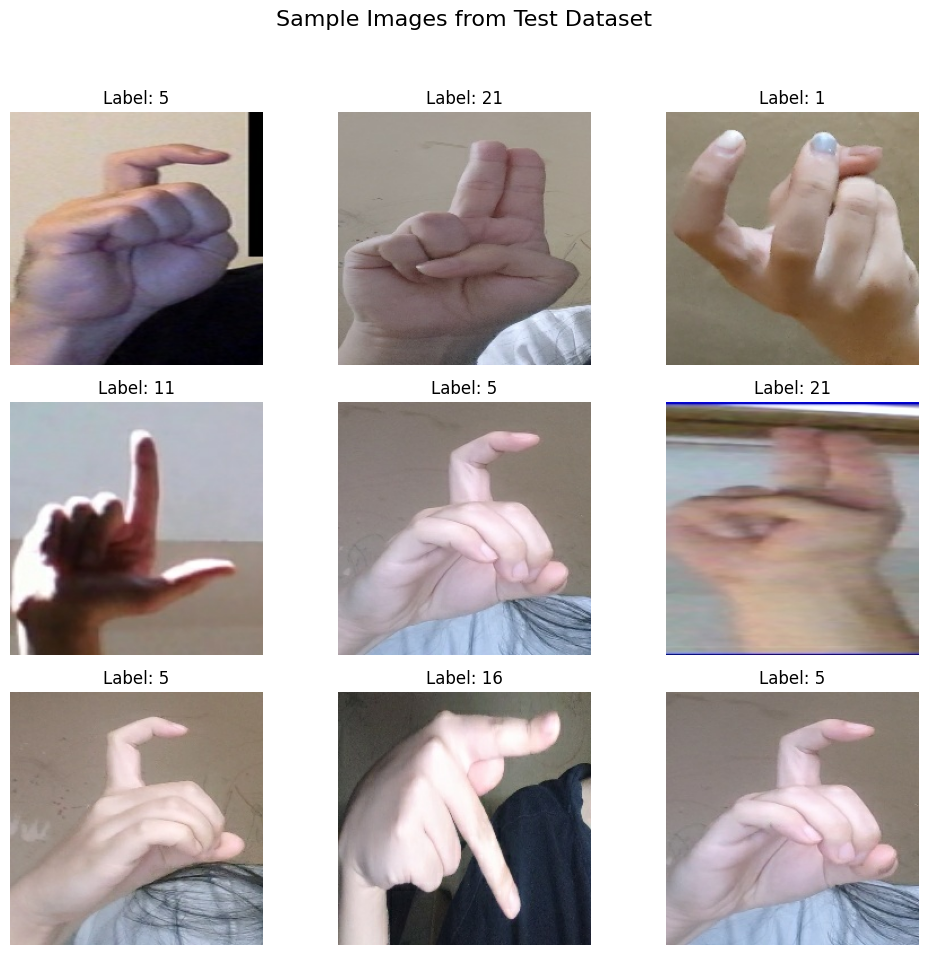

In [ ]:
import matplotlib.pyplot as plt

# Hàm hiển thị hình ảnh
def display_images_from_dataset(dataset, title):
    plt.figure(figsize=(10, 10))
    plt.suptitle(title, fontsize=16)
    for images, labels in dataset.take(1):
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            # Giả sử labels là số nguyên, ta cần chuyển đổi về tên class nếu có
            # Với mục đích hiển thị nhanh, ta chỉ hiển thị số nhãn
            plt.title(f"Label: {labels[i].numpy()}")
            plt.axis("off")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Hiển thị ảnh từ tập huấn luyện
display_images_from_dataset(loaded_train, "Sample Images from Training Dataset")

# Hiển thị ảnh từ tập kiểm định
display_images_from_dataset(loaded_val, "Sample Images from Validation Dataset")

# Hiển thị ảnh từ tập kiểm thử
display_images_from_dataset(loaded_test, "Sample Images from Test Dataset")

In [ ]:
import numpy as np

def count_classes(dataset, dataset_name, class_names):
    print(f"\nThống kê số lượng mẫu trong {dataset_name}:")
    label_counts = {name: 0 for name in class_names}

    # Duyệt qua các batch để đếm nhãn
    for _, labels in dataset:
        unique, counts = np.unique(labels.numpy(), return_counts=True)
        for label_idx, count in zip(unique, counts):
            class_name = class_names[label_idx]
            label_counts[class_name] += count

    # Hiển thị kết quả
    print(f"{'Class':<10} | {'Count':<10}")
    print("-" * 25)
    total = 0
    for cls, count in label_counts.items():
        print(f"{cls:<10} | {count:<10}")
        total += count
    print("-" * 25)
    print(f"Tổng cộng: {total} mẫu")

# Thực hiện đếm cho từng tập dữ liệu
# Biến 'classes' đã được định nghĩa ở các cell trước đó
count_classes(loaded_train, "Tập TRAIN", classes)
count_classes(loaded_val, "Tập VAL", classes)
count_classes(loaded_test, "Tập TEST", classes)


Thống kê số lượng mẫu trong Tập TRAIN:
Class      | Count     
-------------------------
A          | 805       
AA         | 797       
B          | 811       
C          | 810       
D          | 794       
DD         | 790       
E          | 803       
G          | 815       
H          | 819       
I          | 817       
K          | 790       
L          | 782       
M          | 796       
N          | 803       
O          | 817       
OOO        | 807       
P          | 807       
Q          | 811       
R          | 801       
S          | 783       
T          | 786       
U          | 803       
V          | 797       
X          | 770       
Y          | 786       
-------------------------
Tổng cộng: 20000 mẫu

Thống kê số lượng mẫu trong Tập VAL:
Class      | Count     
-------------------------
A          | 97        
AA         | 101       
B          | 97        
C          | 90        
D          | 105       
DD         | 108       
E          | 85        
G      

Kiểm tra dung lượng

In [ ]:
import os

def get_dir_size(path):
    """Tính tổng dung lượng của thư mục (bytes)"""
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            # skip if it is a symbolic link
            if not os.path.islink(fp):
                total_size += os.path.getsize(fp)
    return total_size

# Tính toán dung lượng cho từng tập
paths = {
    "Train Dataset": train_path,
    "Val Dataset": val_path,
    "Test Dataset": test_path
}

print(f"{'Dataset':<20} | {'Size (MB)':<15}")
print("-" * 40)

for name, path in paths.items():
    size_bytes = get_dir_size(path)
    size_mb = size_bytes / (1024 * 1024)
    print(f"{name:<20} | {size_mb:>10.2f} MB")

Dataset              | Size (MB)      
----------------------------------------
Train Dataset        |   11484.49 MB
Val Dataset          |    1433.26 MB
Test Dataset         |    1437.86 MB


### Giải thích về dung lượng lưu trữ

Khi lưu bằng `tf.data.Dataset.save`, dữ liệu được serialize. Hãy tính toán dung lượng lý thuyết của 25,000 ảnh kích thước 224x224x3 (float32):
- Mỗi ảnh: $224 * 224 * 3 * 4$ bytes (float32) $\approx 602,112$ bytes $\approx 0.57$ MB.
- Tổng 25,000 ảnh: $25,000 * 0.57$ MB $\approx 14,250$ MB $\approx 14$ GB.

Con số này khớp với kết quả bạn nhận được.

In [ ]:
import numpy as np

# Kiểm tra kiểu dữ liệu của các phần tử trong dataset
print(f"Cấu trúc dữ liệu: {loaded_train.element_spec}")

# Lấy 1 ảnh để kiểm tra size thực tế trong bộ nhớ
for images, labels in loaded_train.take(1):
    single_img = images[0].numpy()
    nbytes = single_img.nbytes
    print(f"\nKích thước 1 ảnh (bytes): {nbytes}")
    print(f"Kích thước 1 ảnh (MB): {nbytes / (1024*1024):.4f}")

    total_theoretical_gb = (nbytes * 25000) / (1024**3)
    print(f"Dung lượng lý thuyết cho 25,000 ảnh: {total_theoretical_gb:.2f} GB")

Cấu trúc dữ liệu: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))

Kích thước 1 ảnh (bytes): 602112
Kích thước 1 ảnh (MB): 0.5742
Dung lượng lý thuyết cho 25,000 ảnh: 14.02 GB


## 5. Lưu dữ liệu tối ưu dưới dạng TFRecord (Nén mạnh nhất)

TFRecord giúp lưu trữ dữ liệu dưới dạng binary và hỗ trợ nén GZIP, giúp giảm dung lượng đáng kể so với `dataset.save()`.

In [ ]:
def _bytes_feature(value):
    """Trả về một bytes_list từ một string / byte."""
    if isinstance(value, type(tf.constant(0))):
        value = value.numpy()
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _int64_feature(value):
    """Trả về một int64_list từ một bool / enum / int / uint."""
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def serialize_example(image, label):
    """Tạo một tf.train.Example message từ (image, label)."""
    # Mã hóa ảnh ngược lại thành định dạng JPEG để tiết kiệm dung lượng
    image = tf.cast(image, tf.uint8)
    image_encoded = tf.io.encode_jpeg(image)

    feature = {
        'image': _bytes_feature(image_encoded),
        'label': _int64_feature(label),
    }
    example_proto = tf.train.Example(features=tf.train.Features(feature=feature))
    return example_proto.SerializeToString()

def save_dataset_as_tfrecord(dataset, filename):
    print(f"Đang ghi {filename}...")
    options = tf.io.TFRecordOptions(compression_type="GZIP")
    with tf.io.TFRecordWriter(filename, options=options) as writer:
        for image_batch, label_batch in dataset:
            for i in range(len(image_batch)):
                example = serialize_example(image_batch[i], label_batch[i])
                writer.write(example)
    print(f"Hoàn tất: {filename}")

# Tạo thư mục lưu trữ mới
tfrecord_dir = '/content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data/tfrecords'
os.makedirs(tfrecord_dir, exist_ok=True)

# Lưu các tập dữ liệu
save_dataset_as_tfrecord(loaded_train, os.path.join(tfrecord_dir, 'train.tfrecord'))
save_dataset_as_tfrecord(loaded_val, os.path.join(tfrecord_dir, 'val.tfrecord'))
save_dataset_as_tfrecord(loaded_test, os.path.join(tfrecord_dir, 'test.tfrecord'))

Đang ghi /content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data/tfrecords/train.tfrecord...
Hoàn tất: /content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data/tfrecords/train.tfrecord
Đang ghi /content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data/tfrecords/val.tfrecord...
Hoàn tất: /content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data/tfrecords/val.tfrecord
Đang ghi /content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data/tfrecords/test.tfrecord...
Hoàn tất: /content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data/tfrecords/test.tfrecord


In [ ]:
# Kiểm tra dung lượng mới
print(f"{'Dataset':<20} | {'Size (MB)':<15}")
print("-" * 40)
for f in ['train.tfrecord', 'val.tfrecord', 'test.tfrecord']:
    path = os.path.join(tfrecord_dir, f)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"{f:<20} | {size_mb:>10.2f} MB")

Dataset              | Size (MB)      
----------------------------------------
train.tfrecord       |     250.13 MB
val.tfrecord         |      31.31 MB
test.tfrecord        |      31.55 MB


## 6. Đọc dữ liệu từ TFRecord

In [ ]:
tfrecord_dir = '/content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data/tfrecords'

In [ ]:
import os
import tensorflow as tf

In [ ]:
# Định nghĩa cấu trúc feature (phải khớp với lúc lưu)
feature_description = {
    'image': tf.io.FixedLenFeature([], tf.string),
    'label': tf.io.FixedLenFeature([], tf.int64),
}

def _parse_function(example_proto):
    # Giải mã một example
    parsed_features = tf.io.parse_single_example(example_proto, feature_description)

    # Giải mã ảnh JPEG
    image = tf.io.decode_jpeg(parsed_features['image'], channels=3)
    image = tf.image.resize(image, [224, 224])

    label = tf.cast(parsed_features['label'], tf.int32)
    return image, label

def load_tfrecord_dataset(tfrecord_path, batch_size=32):
    if not os.path.exists(tfrecord_path):
        print(f"LỖI: Không tìm thấy tệp tại {tfrecord_path}")
        return None

    raw_dataset = tf.data.TFRecordDataset(tfrecord_path, compression_type="GZIP")
    parsed_dataset = raw_dataset.map(_parse_function)
    return parsed_dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

# Đường dẫn các tệp
train_tf_path = os.path.join(tfrecord_dir, 'train.tfrecord')
val_tf_path = os.path.join(tfrecord_dir, 'val.tfrecord')
test_tf_path = os.path.join(tfrecord_dir, 'test.tfrecord')

# Load dataset
train_tf_ds = load_tfrecord_dataset(train_tf_path)
val_tf_ds = load_tfrecord_dataset(val_tf_path)
test_tf_ds = load_tfrecord_dataset(test_tf_path)

# Kiểm tra thử 1 batch từ tập test
if test_tf_ds is not None:
    try:
        for imgs, lbls in test_tf_ds.take(1):
            print(f"Đã load thành công TFRecord!")
            print(f"Shape của batch ảnh: {imgs.shape}")
            print(f"Shape của batch nhãn: {lbls.shape}")
    except Exception as e:
        print(f"Lỗi khi đọc dữ liệu: {e}")

Đã load thành công TFRecord!
Shape của batch ảnh: (32, 224, 224, 3)
Shape của batch nhãn: (32,)
